# Part 3 - Zero-Shot Transfer Learning & SOTA Transfer from TFHub

# SECTION A: Zero-Shot Classification with CLIP (OpenAI)

In [1]:
!pip install -q git+https://github.com/openai/CLIP.git
import torch
import clip
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 54.7 MB/s eta 0:00:00


# Load CLIP model

In [2]:
# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 69.5MiB/s]


In [3]:
# Load sample image
url = "https://raw.githubusercontent.com/openai/CLIP/main/CLIP.png"
pil_image = Image.open(BytesIO(requests.get(url).content))
image = preprocess(pil_image).unsqueeze(0).to(device)

In [4]:
# Define class names (zero-shot labels)
text_descriptions = ["a diagram", "a dog", "a cat", "a screenshot", "a photo of a face"]
text_tokens = clip.tokenize(text_descriptions).to(device)

# Zero-shot prediction

In [5]:
# Zero-shot prediction
with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text_tokens)
    logits_per_image, logits_per_text = model(image, text_tokens)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

# Probability Prediction

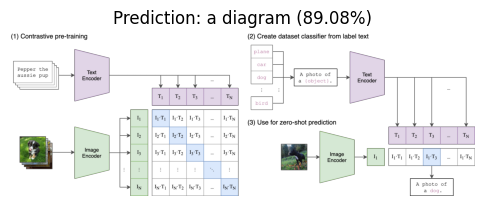

In [6]:
# Display result with probabilities
plt.figure(figsize=(6, 3))
plt.imshow(pil_image)
plt.axis("off")
plt.title(f"Prediction: {text_descriptions[probs.argmax()]} ({100*probs.max():.2f}%)")
plt.show()

# Probability Visualization

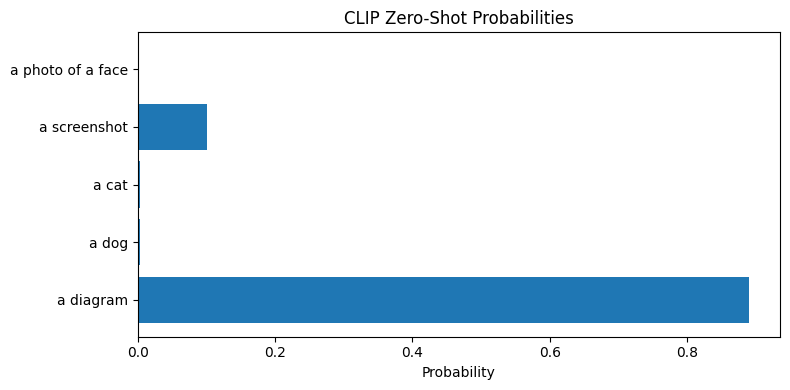

In [7]:
# Plot all probabilities
plt.figure(figsize=(8, 4))
plt.barh(text_descriptions, probs[0])
plt.title("CLIP Zero-Shot Probabilities")
plt.xlabel("Probability")
plt.tight_layout()
plt.show()

# SECTION B: SOTA Transfer Learning using BigTransfer (BiT) from TFHub

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

## Load Dataset

In [2]:
# Load Flowers Dataset
(train_ds, test_ds), info = tfds.load("tf_flowers", split=["train[:80%]", "train[80%:]"],
                                      as_supervised=True, with_info=True)
CLASS_NAMES = info.features['label'].names
NUM_CLASSES = len(CLASS_NAMES)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.XIF9UY_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


## Preprocessing

In [3]:
# Preprocessing
def preprocess(image, label):
    image = tf.image.resize(image, [224, 224]) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).batch(32).prefetch(1)
test_ds = test_ds.map(preprocess).batch(32).prefetch(1)

## Load feature extractor

In [4]:
# Load feature extractor only
extractor = hub.load("https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4")

In [5]:
# Convert to numpy features
def extract_features(dataset):
    features, labels = [], []
    # Store raw images for visualization
    raw_images = []
    for images, lbls in dataset:
        emb = extractor(images)
        features.append(emb.numpy())
        labels.append(lbls.numpy())
        # Append raw images to the list
        raw_images.extend(images.numpy())
    return np.concatenate(features), np.concatenate(labels), np.array(raw_images)

X_train, y_train, _ = extract_features(train_ds)  # _ for unused raw_images from train_ds
X_test, y_test, raw_images_test = extract_features(test_ds)

## Train classifier

In [6]:
# Train classifier on top of frozen features
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

## Accuracy & Confusion Matrix

Test Accuracy: 0.92


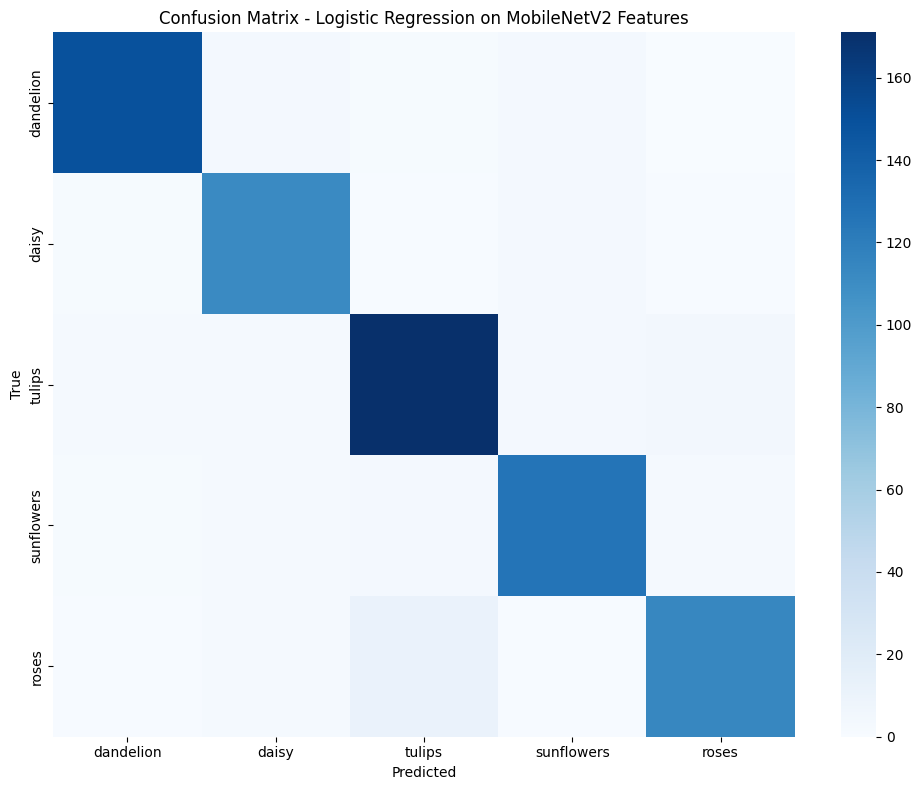

In [7]:
# Accuracy & Confusion Matrix
acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc:.2f}")

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - Logistic Regression on MobileNetV2 Features")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Results Comparision

<ipython-input-8-35fafdb8f866>:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-35fafdb8f866>:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


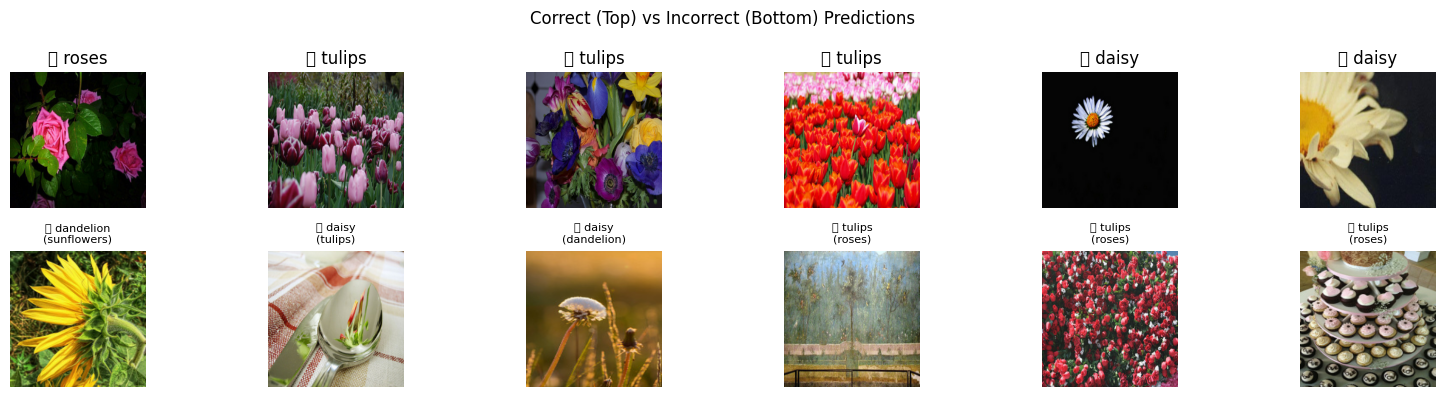

In [8]:
# Visual comparison of flowers: correct vs incorrect
correct = [i for i in range(len(y_test)) if y_test[i] == preds[i]]
incorrect = [i for i in range(len(y_test)) if y_test[i] != preds[i]]

plt.figure(figsize=(16, 4))
for idx, i in enumerate(correct[:6]):
    plt.subplot(2, 6, idx+1)
    plt.imshow(raw_images_test[i]) # raw_images_test is now available
    plt.title(f"✅ {CLASS_NAMES[preds[i]]}")
    plt.axis("off")
for idx, i in enumerate(incorrect[:6]):
    plt.subplot(2, 6, idx+7)
    plt.imshow(raw_images_test[i]) # raw_images_test is now available
    true_lbl = CLASS_NAMES[y_test[i]]
    pred_lbl = CLASS_NAMES[preds[i]]
    plt.title(f"❌ {pred_lbl}\n({true_lbl})", fontsize=8)
    plt.axis("off")
plt.suptitle("Correct (Top) vs Incorrect (Bottom) Predictions")
plt.tight_layout()
plt.show()